In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dbio3 import load_data
from wordcloud import WordCloud
from collections import Counter
from konlpy.tag import Mecab
mecab = Mecab()

In [2]:
df = pd.read_csv("./data/fintech_news3.csv")
df

,날짜,제목,원문링크,뉴스본문
0,2025-11-19,"한국핀테크지원센터, ‘제18회 대한민국소통어워즈’에서 2년 연속 3개 부문 대상 수상",https://www.joongang.co.kr/article/25383037,NaN
1,2025-11-19,[한국핀테크지원센터] 2025 핀테크 전문가(개발자) 과정 ‘FinBoost Aca...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...
2,2025-11-19,[한국핀테크산업협회] 네트워킹 행사 '핀테크 커넥팅 데이 2025' 개최(11.26...,https://fintech.or.kr/web/board/boardContentsV...,"안녕하세요. 핀테크산업협회 사무국입니다.협회는 핀테크 기업과 금융기관, AFA 등 ..."
3,2025-11-19,[한국핀테크지원센터] (온라인) 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요. 한국핀테크지원센터입니다.2025년 금융특화 계층별 AI역량강화 과정 ‘...
4,2025-11-19,[한국핀테크지원센터] 2025년 핀테크기업 온라인 채용관 (사람인 saramin) ...,https://fintech.or.kr/web/board/boardContentsV...,2025년‘핀테크기업 온라인 채용관’ (사람인 saramin) 참여 기업 모집 ...
...,...,...,...,...
11746,2024-12-16,수렁에 빠진 중국 경제... “몰락 중산층 2000만명 우버 택시로 몰렸다”,https://n.news.naver.com/mnews/article/023/000...,"\n\n[온차이나]중국 민간 경제 전문가들 “통계보다 훨씬 더 나쁘고, 성장시대 ..."
11747,2024-12-16,"""관세 폭탄 때문에 내년엔 더 비싸""…생필품·가전 등 사재기 열풍 부는 美",https://n.news.naver.com/mnews/article/277/000...,"\n\nWSJ ""사재기가 인플레이션 부추길 수도"" 지적미국의 일부 소비자들이 도널드..."
11748,2024-12-16,"구글·메타 등과 AI칩 합작… 브로드컴, 엔비디아 대항마로",https://n.news.naver.com/mnews/article/023/000...,\n\n시총도 1조달러 돌파\n\n\n\n\t\t\t\t\t\t\t\t\t\t미국 ...
11749,2024-12-16,"美, 중국의 중동·동남아 통한 AI 반도체 우회 조달도 막는다",https://n.news.naver.com/mnews/article/023/000...,\n\n수출 물량 상한제 추진\t\t\t\t\t\t\t미국 정부가 국가 안보를 이유...


In [3]:
def text_clean(x):
    # 한글, 영문대소문자, 숫자만 남기고 모두 제거
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9]', " ", x)
    cleaned = cleaned.replace("  ", " ").replace("  ", " ").strip()
    return cleaned

In [4]:
df = df.dropna()
df

,날짜,제목,원문링크,뉴스본문
1,2025-11-19,[한국핀테크지원센터] 2025 핀테크 전문가(개발자) 과정 ‘FinBoost Aca...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...
2,2025-11-19,[한국핀테크산업협회] 네트워킹 행사 '핀테크 커넥팅 데이 2025' 개최(11.26...,https://fintech.or.kr/web/board/boardContentsV...,"안녕하세요. 핀테크산업협회 사무국입니다.협회는 핀테크 기업과 금융기관, AFA 등 ..."
3,2025-11-19,[한국핀테크지원센터] (온라인) 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요. 한국핀테크지원센터입니다.2025년 금융특화 계층별 AI역량강화 과정 ‘...
4,2025-11-19,[한국핀테크지원센터] 2025년 핀테크기업 온라인 채용관 (사람인 saramin) ...,https://fintech.or.kr/web/board/boardContentsV...,2025년‘핀테크기업 온라인 채용관’ (사람인 saramin) 참여 기업 모집 ...
5,2025-11-19,"금융위, 5대 금융지주 불러모아 “포용금융 적극 역할” 당부",https://n.news.naver.com/mnews/article/016/000...,"\n\n‘포용금융 소통·점검회의’ 개최기관별 지원현황, 준비상황 점검\n\n\n\n..."
...,...,...,...,...
11746,2024-12-16,수렁에 빠진 중국 경제... “몰락 중산층 2000만명 우버 택시로 몰렸다”,https://n.news.naver.com/mnews/article/023/000...,"\n\n[온차이나]중국 민간 경제 전문가들 “통계보다 훨씬 더 나쁘고, 성장시대 ..."
11747,2024-12-16,"""관세 폭탄 때문에 내년엔 더 비싸""…생필품·가전 등 사재기 열풍 부는 美",https://n.news.naver.com/mnews/article/277/000...,"\n\nWSJ ""사재기가 인플레이션 부추길 수도"" 지적미국의 일부 소비자들이 도널드..."
11748,2024-12-16,"구글·메타 등과 AI칩 합작… 브로드컴, 엔비디아 대항마로",https://n.news.naver.com/mnews/article/023/000...,\n\n시총도 1조달러 돌파\n\n\n\n\t\t\t\t\t\t\t\t\t\t미국 ...
11749,2024-12-16,"美, 중국의 중동·동남아 통한 AI 반도체 우회 조달도 막는다",https://n.news.naver.com/mnews/article/023/000...,\n\n수출 물량 상한제 추진\t\t\t\t\t\t\t미국 정부가 국가 안보를 이유...


In [5]:
df.loc[:, '제목'] = df['제목'].apply(text_clean)

In [7]:
df.loc[:, '뉴스본문'] = df['뉴스본문'].apply(text_clean)
df

,날짜,제목,원문링크,뉴스본문
1,2025-11-19,한국핀테크지원센터 2025 핀테크 전문가 개발자 과정 FinBoost Academy...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...
2,2025-11-19,한국핀테크산업협회 네트워킹 행사 핀테크 커넥팅 데이 2025 개최 11 26 신청 ...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 핀테크산업협회 사무국입니다 협회는 핀테크 기업과 금융기관 AFA 등 해외...
3,2025-11-19,한국핀테크지원센터 온라인 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생 모집 상시,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 한국핀테크지원센터입니다 2025년 금융특화 계층별 AI역량강화 과정 핀테...
4,2025-11-19,한국핀테크지원센터 2025년 핀테크기업 온라인 채용관 사람인 saramin 참여기업...,https://fintech.or.kr/web/board/boardContentsV...,2025년 핀테크기업 온라인 채용관 사람인 saramin 참여 기업 모집 한국핀테크...
5,2025-11-19,금융위 5대 금융지주 불러모아 포용금융 적극 역할 당부,https://n.news.naver.com/mnews/article/016/000...,포용금융 소통 점검회의 개최기관별 지원현황 준비상황 점검 금융위원회 제공 헤럴드경제...
...,...,...,...,...
11746,2024-12-16,수렁에 빠진 중국 경제 몰락 중산층 2000만명 우버 택시로 몰렸다,https://n.news.naver.com/mnews/article/023/000...,온차이나 중국 민간 경제 전문가들 통계보다 훨씬 더 나쁘고 성장시대 저문다 경고 연...
11747,2024-12-16,관세 폭탄 때문에 내년엔 더 비싸 생필품 가전 등 사재기 열풍 부는,https://n.news.naver.com/mnews/article/277/000...,WSJ 사재기가 인플레이션 부추길 수도 지적미국의 일부 소비자들이 도널드 트럼프 미...
11748,2024-12-16,구글 메타 등과 AI칩 합작 브로드컴 엔비디아 대항마로,https://n.news.naver.com/mnews/article/023/000...,시총도 1조달러 돌파 미국 반도체 기업 브로드컴이 13일 처음으로 시가총액 이하 시...
11749,2024-12-16,중국의 중동 동남아 통한 AI 반도체 우회 조달도 막는다,https://n.news.naver.com/mnews/article/023/000...,수출 물량 상한제 추진 미국 정부가 국가 안보를 이유로 특정 국가들에 인공지능 AI...


In [8]:
df['tokens'] = df['뉴스본문'].apply(mecab.nouns)
df

/tmp/ipykernel_633/3460636742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens'] = df['뉴스본문'].apply(mecab.nouns)


,날짜,제목,원문링크,뉴스본문,tokens
1,2025-11-19,한국핀테크지원센터 2025 핀테크 전문가 개발자 과정 FinBoost Academy...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...,"[한국, 핀테크, 지원, 센터, 핀테크, 산업, 성장, 기여, 최신, 트렌드, 반영..."
2,2025-11-19,한국핀테크산업협회 네트워킹 행사 핀테크 커넥팅 데이 2025 개최 11 26 신청 ...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 핀테크산업협회 사무국입니다 협회는 핀테크 기업과 금융기관 AFA 등 해외...,"[안녕, 핀테크, 산업, 협회, 사무국, 협회, 핀테크, 기업, 금융, 기관, 등,..."
3,2025-11-19,한국핀테크지원센터 온라인 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생 모집 상시,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 한국핀테크지원센터입니다 2025년 금융특화 계층별 AI역량강화 과정 핀테...,"[안녕, 한국, 핀테크, 지원, 센터, 년, 금융, 특화, 계층, 역량, 강화, 과..."
4,2025-11-19,한국핀테크지원센터 2025년 핀테크기업 온라인 채용관 사람인 saramin 참여기업...,https://fintech.or.kr/web/board/boardContentsV...,2025년 핀테크기업 온라인 채용관 사람인 saramin 참여 기업 모집 한국핀테크...,"[년, 핀테크, 기업, 온라인, 용관, 사람, 참여, 기업, 모집, 한국, 핀테크,..."
5,2025-11-19,금융위 5대 금융지주 불러모아 포용금융 적극 역할 당부,https://n.news.naver.com/mnews/article/016/000...,포용금융 소통 점검회의 개최기관별 지원현황 준비상황 점검 금융위원회 제공 헤럴드경제...,"[포용, 금융, 소통, 점검, 회의, 개최, 기관, 지원, 현황, 준비, 상황, 점..."
...,...,...,...,...,...
11746,2024-12-16,수렁에 빠진 중국 경제 몰락 중산층 2000만명 우버 택시로 몰렸다,https://n.news.naver.com/mnews/article/023/000...,온차이나 중국 민간 경제 전문가들 통계보다 훨씬 더 나쁘고 성장시대 저문다 경고 연...,"[온차, 중국, 민간, 경제, 전문가, 통계, 성장, 시대, 경고, 연간, 장률, ..."
11747,2024-12-16,관세 폭탄 때문에 내년엔 더 비싸 생필품 가전 등 사재기 열풍 부는,https://n.news.naver.com/mnews/article/277/000...,WSJ 사재기가 인플레이션 부추길 수도 지적미국의 일부 소비자들이 도널드 트럼프 미...,"[사재기, 인플레이션, 수, 지적, 미국, 일부, 소비자, 도널드, 트럼프, 미국,..."
11748,2024-12-16,구글 메타 등과 AI칩 합작 브로드컴 엔비디아 대항마로,https://n.news.naver.com/mnews/article/023/000...,시총도 1조달러 돌파 미국 반도체 기업 브로드컴이 13일 처음으로 시가총액 이하 시...,"[시, 총, 조, 달러, 돌파, 미국, 반도체, 기업, 브로드컴, 일, 처음, 시가..."
11749,2024-12-16,중국의 중동 동남아 통한 AI 반도체 우회 조달도 막는다,https://n.news.naver.com/mnews/article/023/000...,수출 물량 상한제 추진 미국 정부가 국가 안보를 이유로 특정 국가들에 인공지능 AI...,"[수출, 물량, 상한, 추진, 미국, 정부, 국가, 안보, 이유, 특정, 국가, 인..."


In [9]:
df.loc[:, 'tokens'] = df['tokens'].apply(lambda x: [word for word in x if len(word) > 1])
df

,날짜,제목,원문링크,뉴스본문,tokens
1,2025-11-19,한국핀테크지원센터 2025 핀테크 전문가 개발자 과정 FinBoost Academy...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...,"[한국, 핀테크, 지원, 센터, 핀테크, 산업, 성장, 기여, 최신, 트렌드, 반영..."
2,2025-11-19,한국핀테크산업협회 네트워킹 행사 핀테크 커넥팅 데이 2025 개최 11 26 신청 ...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 핀테크산업협회 사무국입니다 협회는 핀테크 기업과 금융기관 AFA 등 해외...,"[안녕, 핀테크, 산업, 협회, 사무국, 협회, 핀테크, 기업, 금융, 기관, 해외..."
3,2025-11-19,한국핀테크지원센터 온라인 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생 모집 상시,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 한국핀테크지원센터입니다 2025년 금융특화 계층별 AI역량강화 과정 핀테...,"[안녕, 한국, 핀테크, 지원, 센터, 금융, 특화, 계층, 역량, 강화, 과정, ..."
4,2025-11-19,한국핀테크지원센터 2025년 핀테크기업 온라인 채용관 사람인 saramin 참여기업...,https://fintech.or.kr/web/board/boardContentsV...,2025년 핀테크기업 온라인 채용관 사람인 saramin 참여 기업 모집 한국핀테크...,"[핀테크, 기업, 온라인, 용관, 사람, 참여, 기업, 모집, 한국, 핀테크, 지원..."
5,2025-11-19,금융위 5대 금융지주 불러모아 포용금융 적극 역할 당부,https://n.news.naver.com/mnews/article/016/000...,포용금융 소통 점검회의 개최기관별 지원현황 준비상황 점검 금융위원회 제공 헤럴드경제...,"[포용, 금융, 소통, 점검, 회의, 개최, 기관, 지원, 현황, 준비, 상황, 점..."
...,...,...,...,...,...
11746,2024-12-16,수렁에 빠진 중국 경제 몰락 중산층 2000만명 우버 택시로 몰렸다,https://n.news.naver.com/mnews/article/023/000...,온차이나 중국 민간 경제 전문가들 통계보다 훨씬 더 나쁘고 성장시대 저문다 경고 연...,"[온차, 중국, 민간, 경제, 전문가, 통계, 성장, 시대, 경고, 연간, 장률, ..."
11747,2024-12-16,관세 폭탄 때문에 내년엔 더 비싸 생필품 가전 등 사재기 열풍 부는,https://n.news.naver.com/mnews/article/277/000...,WSJ 사재기가 인플레이션 부추길 수도 지적미국의 일부 소비자들이 도널드 트럼프 미...,"[사재기, 인플레이션, 지적, 미국, 일부, 소비자, 도널드, 트럼프, 미국, 대통..."
11748,2024-12-16,구글 메타 등과 AI칩 합작 브로드컴 엔비디아 대항마로,https://n.news.naver.com/mnews/article/023/000...,시총도 1조달러 돌파 미국 반도체 기업 브로드컴이 13일 처음으로 시가총액 이하 시...,"[달러, 돌파, 미국, 반도체, 기업, 브로드컴, 처음, 시가총액, 달러, 돌파, ..."
11749,2024-12-16,중국의 중동 동남아 통한 AI 반도체 우회 조달도 막는다,https://n.news.naver.com/mnews/article/023/000...,수출 물량 상한제 추진 미국 정부가 국가 안보를 이유로 특정 국가들에 인공지능 AI...,"[수출, 물량, 상한, 추진, 미국, 정부, 국가, 안보, 이유, 특정, 국가, 인..."


# 단어 빈도수 체크

In [10]:
all_word_list = []
for row in df['tokens'].tolist():
    all_word_list += row

In [11]:
all_word_list[:3]

['한국', '핀테크', '지원']

In [12]:
len(all_word_list)

3172233

In [13]:
stopwords = set([
    '은행', '어플', '뱅킹', '앱','서비스', '고객',
    '하나','국민','신한','우리','토스','카드','금융','기업','핀테크','한국','지난해'
])

In [14]:
filtered = [word for word in all_word_list if len(word) > 1 and word not in stopwords]

In [15]:
len(filtered)

2934542

In [16]:
filtered[:10]

['지원', '센터', '산업', '성장', '기여', '최신', '트렌드', '반영', '교육', '과정']

In [17]:
word_freq = Counter(filtered)
word_freq

Counter({'대출': 25596,
         '금리': 20487,
         '투자': 20360,
         '시장': 20282,
         '보험': 19701,
         '지원': 19615,
         '자산': 16353,
         '미국': 14866,
         '가능': 12925,
         '상품': 12536,
         '기준': 12202,
         '코인': 10994,
         '뱅크': 10798,
         '결제': 10492,
         '제공': 10319,
         '스테이': 9534,
         '달러': 9349,
         '규제': 9309,
         '기술': 9010,
         '거래': 8977,
         '경우': 8925,
         '사업': 8769,
         '확대': 8720,
         '국내': 8689,
         '평가': 8635,
         '중국': 8620,
         '관리': 8582,
         '디지털': 8458,
         '필요': 8375,
         '관련': 8259,
         '규모': 8192,
         '올해': 8185,
         '증가': 8121,
         '수익': 8077,
         '당국': 7835,
         '자금': 7808,
         '정책': 7776,
         '증권': 7741,
         '정부': 7579,
         '이상': 7511,
         '제도': 7503,
         '신용': 7477,
         '대상': 7454,
         '최근': 7357,
         '신청': 7291,
         '강화': 7237,
         '정보': 71

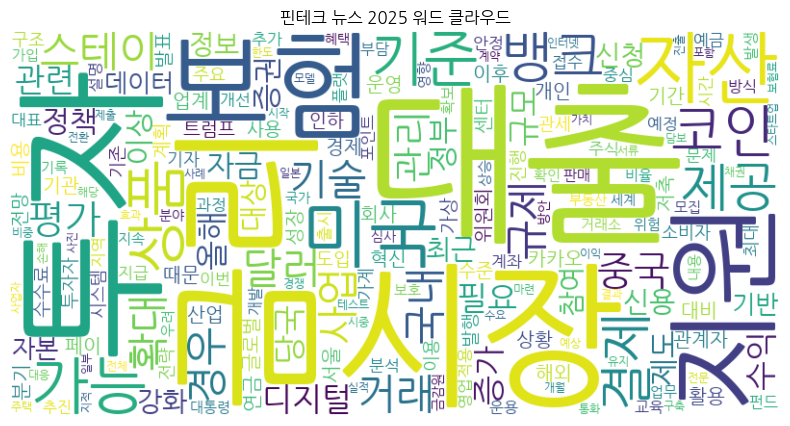

In [18]:
wc = WordCloud(
        font_path='NanumGothic.ttf',
        background_color='white',
        width=800,
        height=400).generate_from_frequencies(word_freq)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("핀테크 뉴스 2025 워드 클라우드")
plt.show()

# word2vec, LDA 토픽 모델링, T-sne 시각화

In [19]:
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

In [20]:
def find_optimal_topics(tokenized_texts, start=2, end=8):
    
    # gensim으로 BoW(숫자로 인코딩 된 단어 모음)
    dictionary = corpora.Dictionary(tokenized_texts)
    vectorizer = CountVectorizer(tokenizer=lambda x: x, lowercase=False)
    
    try:
        doc_term_matrix = vectorizer.fit_transform(tokenized_texts)
    except:
        print("벡터화중 오류발생, 기본 토픽 수 2개 반환")
        return start
    
    best_score = -1
    best_n = start
    
    # LDA 분석
    for n_topics in range(start, end+1):
        lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
        lda_model.fit(doc_term_matrix)
        
        feature_names = vectorizer.get_feature_names_out()
        # 상위 10개의 단어를 순서대로 추출
        topics = [[feature_names[i] for i in topic.argsort()[:-11:-1]] for topic in lda_model.components_]
        
        # 응집도 계산
        cm = CoherenceModel(topics=topics, texts=tokenized_texts, dictionary=dictionary, coherence="c_v")
        score = cm.get_coherence()
        print(f"토픽수: {n_topics}, Coherence Score: {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_n = n_topics
    
    print(f"최적 토픽수: {best_n} (Score: {best_score:.4f})")
    return best_n

In [21]:
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=2, workers=8, sg=1)

In [22]:
def topic_modeling(tokenized_texts_df, w2v_model, month):
    
    print("--- 토픽 모델링 시작 ---")
    
    # 최적 토픽 수 탐색
    try:
        print(f"\n핀테크 뉴스 2025 {month}월 최적 토픽 수 계산 중...")
        best_k = find_optimal_topics(tokenized_texts_df)
    except Exception as e:
        print(f"\n핀테크 뉴스 2025 {month}월 최적 토픽 수 계산 오류 {e}")

    # CountVectorizer
    try:
        vectorizer = CountVectorizer(tokenizer=lambda x: x, token_pattern=None, lowercase=False, max_df=0.9, min_df=5)
        review_vec = vectorizer.fit_transform(tokenized_texts_df)

        if review_vec.shape[1] == 0:
            print(f"\n핀테크 뉴스 2025 {month}월 min_df 조건 만족 단어 없음 - 스킵")


        # LDA 학습
        lda_model = LatentDirichletAllocation(n_components=best_k, random_state=42)
        lda_model.fit(review_vec)

        words = vectorizer.get_feature_names_out()

        # 토픽별 상위 단어 출력 + 전체 단어 set에 모으기
        all_topic_words = set()
        print(f"\n핀테크 뉴스 2025 {month}월 토픽별 상위 단어 (k={best_k})")
        print("=" * 60)
        for i, topic in enumerate(lda_model.components_):
            top = [words[idx] for idx in topic.argsort()[-10:]]
            print(f"Topic #{i}: {top}")
            all_topic_words.update(top)

        print(f"\n핀테크 뉴스 2025 {month}월 토픽 단어 총 {len(all_topic_words)}개")

        # 토픽 단어 중 word2vec에 있는 것만 사용해서 시각화
        valid_words = [word for word in all_topic_words if word in w2v_model.wv]
        print(f"word2vec에 포함된 토픽 단어 수: {len(valid_words)}개")

        vectors = np.array([w2v_model.wv[word] for word in valid_words])

        tsne_perplexity = min(10, len(valid_words) -1)
        if tsne_perplexity < 2:
            tsne_perplexity = 2

        tsne = TSNE(n_components=2, random_state=42, perplexity=tsne_perplexity)
        reduced_vecs = tsne.fit_transform(vectors)

        # tsne 시각화

        plt.figure(figsize=(10, 6))
        for i, word in enumerate(valid_words):
            x, y = reduced_vecs[i]
            plt.scatter(x, y)
            plt.text(x + 0.01, y +0.01, word, fontsize=12)
        plt.title(f"\n핀테크 뉴스 2025 {month}월 토픽 단어의 Word2Vec 유사도 기반 시각화 (T-SNE)")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(e)

In [23]:
df.loc[:, '날짜'] = pd.to_datetime(df['날짜'])
df

,날짜,제목,원문링크,뉴스본문,tokens
1,2025-11-19 00:00:00,한국핀테크지원센터 2025 핀테크 전문가 개발자 과정 FinBoost Academy...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 산업 성장에 기여하고자 최신트렌드를 반영한 교육과정을 기...,"[한국, 핀테크, 지원, 센터, 핀테크, 산업, 성장, 기여, 최신, 트렌드, 반영..."
2,2025-11-19 00:00:00,한국핀테크산업협회 네트워킹 행사 핀테크 커넥팅 데이 2025 개최 11 26 신청 ...,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 핀테크산업협회 사무국입니다 협회는 핀테크 기업과 금융기관 AFA 등 해외...,"[안녕, 핀테크, 산업, 협회, 사무국, 협회, 핀테크, 기업, 금융, 기관, 해외..."
3,2025-11-19 00:00:00,한국핀테크지원센터 온라인 핀테크를 통한 금융 AI 트렌드와 혁신 사례 교육생 모집 상시,https://fintech.or.kr/web/board/boardContentsV...,안녕하세요 한국핀테크지원센터입니다 2025년 금융특화 계층별 AI역량강화 과정 핀테...,"[안녕, 한국, 핀테크, 지원, 센터, 금융, 특화, 계층, 역량, 강화, 과정, ..."
4,2025-11-19 00:00:00,한국핀테크지원센터 2025년 핀테크기업 온라인 채용관 사람인 saramin 참여기업...,https://fintech.or.kr/web/board/boardContentsV...,2025년 핀테크기업 온라인 채용관 사람인 saramin 참여 기업 모집 한국핀테크...,"[핀테크, 기업, 온라인, 용관, 사람, 참여, 기업, 모집, 한국, 핀테크, 지원..."
5,2025-11-19 00:00:00,금융위 5대 금융지주 불러모아 포용금융 적극 역할 당부,https://n.news.naver.com/mnews/article/016/000...,포용금융 소통 점검회의 개최기관별 지원현황 준비상황 점검 금융위원회 제공 헤럴드경제...,"[포용, 금융, 소통, 점검, 회의, 개최, 기관, 지원, 현황, 준비, 상황, 점..."
...,...,...,...,...,...
11746,2024-12-16 00:00:00,수렁에 빠진 중국 경제 몰락 중산층 2000만명 우버 택시로 몰렸다,https://n.news.naver.com/mnews/article/023/000...,온차이나 중국 민간 경제 전문가들 통계보다 훨씬 더 나쁘고 성장시대 저문다 경고 연...,"[온차, 중국, 민간, 경제, 전문가, 통계, 성장, 시대, 경고, 연간, 장률, ..."
11747,2024-12-16 00:00:00,관세 폭탄 때문에 내년엔 더 비싸 생필품 가전 등 사재기 열풍 부는,https://n.news.naver.com/mnews/article/277/000...,WSJ 사재기가 인플레이션 부추길 수도 지적미국의 일부 소비자들이 도널드 트럼프 미...,"[사재기, 인플레이션, 지적, 미국, 일부, 소비자, 도널드, 트럼프, 미국, 대통..."
11748,2024-12-16 00:00:00,구글 메타 등과 AI칩 합작 브로드컴 엔비디아 대항마로,https://n.news.naver.com/mnews/article/023/000...,시총도 1조달러 돌파 미국 반도체 기업 브로드컴이 13일 처음으로 시가총액 이하 시...,"[달러, 돌파, 미국, 반도체, 기업, 브로드컴, 처음, 시가총액, 달러, 돌파, ..."
11749,2024-12-16 00:00:00,중국의 중동 동남아 통한 AI 반도체 우회 조달도 막는다,https://n.news.naver.com/mnews/article/023/000...,수출 물량 상한제 추진 미국 정부가 국가 안보를 이유로 특정 국가들에 인공지능 AI...,"[수출, 물량, 상한, 추진, 미국, 정부, 국가, 안보, 이유, 특정, 국가, 인..."


In [24]:
df['날짜'] = pd.to_datetime(df['날짜'])

/tmp/ipykernel_633/2071769210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['날짜'] = pd.to_datetime(df['날짜'])


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11686 entries, 1 to 11750
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      11686 non-null  datetime64[ns]
 1   제목      11686 non-null  object        
 2   원문링크    11686 non-null  object        
 3   뉴스본문    11686 non-null  object        
 4   tokens  11686 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 547.8+ KB


In [26]:
df.loc[df['날짜'].dt.month == 1]

,날짜,제목,원문링크,뉴스본문,tokens
10327,2025-01-31,한국핀테크지원센터x구름 2025 핀테크 벤처 스타트업 아카데미 핀테크 인턴십 코스 ...,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터x구름 2025 핀테크 벤처 스타트업 아카데미 핀테크 인턴십 코스 ...,"[한국, 핀테크, 지원, 센터, 구름, 핀테크, 벤처, 스타트업, 아카데미, 핀테크..."
10328,2025-01-31,공고 2024년도 한국핀테크지원센터 종합 홍보대행사 선정 공고 2 7 17 00,https://fintech.or.kr/web/board/boardContentsV...,한국핀테크지원센터는 핀테크 및 센터가 주관하는 사업 및 행사 등을핀테크 기업 금융기...,"[한국, 핀테크, 지원, 센터, 핀테크, 센터, 주관, 사업, 행사, 핀테크, 기업..."
10329,2025-01-31,금융위 IFRS재단 등 회계분야 국제기구 국내 인사 간담회,https://n.news.naver.com/mnews/article/018/000...,국내 인사 2명 회계분야 국제기구 신규 진출IFRS 제개정 등 주요 의제에 국내 의...,"[국내, 인사, 회계, 분야, 국제기구, 신규, 진출, 개정, 주요, 의제, 국내,..."
10330,2025-01-31,11월 WGBI 편입 대비 금융당국 외국인 투자자 위한 국채통합매매계좌 도입,https://n.news.naver.com/mnews/article/366/000...,외국 금융기관의 외국인 대상 장외 채권 공매도 허용 금융당국이 외국 금융투자업자가 ...,"[외국, 금융, 기관, 외국인, 대상, 장외, 채권, 공매도, 허용, 금융, 당국,..."
10331,2025-01-31,금감원 급격한 엔캐리 청산 유인 낮아 대외여건 면밀히 모니터링,https://n.news.naver.com/mnews/article/014/000...,이복현 금융감독원장이 24일 오전 서울 영등포구 금감원에서 금융상황 점검회의 를 주...,"[복현, 금융, 감독, 원장, 오전, 서울, 영등포구, 금감원, 금융, 상황, 점검..."
...,...,...,...,...,...
11179,2025-01-02,당장 돈 안되고 성능향상 기대 못 미쳐도 세계는 AI인프라 영끌,https://n.news.naver.com/mnews/article/029/000...,오픈AI 오리온 데이터 늘려도성능 큰 차이 없어 난관 봉착기업 70 AI 투자 위험...,"[오픈, 오리온, 데이터, 성능, 차이, 난관, 봉착, 기업, 투자, 위험, 요소,..."
11180,2025-01-02,트럼프 2 0시대 중국 미 동맹국 이탈 기대하며 버티기 다시 만난 트럼프,https://n.news.naver.com/mnews/article/032/000...,2019년 6월29일 일본 오사카에서 열린 주요 20개국 G20 정상회담에서 시진핑...,"[일본, 오사카, 주요, 개국, 정상, 회담, 시진핑, 중국, 국가, 주석, 도널드..."
11181,2025-01-02,51번째 주 모욕 당했는데 트럼프에 찍소리 못하는 이유 김리안의 에네르기파WAR,https://n.news.naver.com/mnews/article/015/000...,글로벌 전기 무기화 트럼프 관세 협박에 캐나다 최후의 보루까지 잃을까 전전긍긍 이 ...,"[글로벌, 전기, 무기, 트럼프, 관세, 협박, 캐나다, 최후, 보루, 전전긍긍, ..."
11182,2025-01-02,산업은행 2025년 상반기 KDB NextONE 참여 스타트업 모집 서울 부산 25...,https://fintech.or.kr/web/board/boardContentsV...,2025년 상반기 KDB NextONE 참여 스타트업 모집 공고 1 공 고 명 20...,"[상반기, 참여, 스타트업, 모집, 공고, 상반기, 대한민국, 미래, 성장, 혁신,..."


--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 1월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4708
토픽수: 3, Coherence Score: 0.4060
토픽수: 4, Coherence Score: 0.4848
토픽수: 5, Coherence Score: 0.4947
토픽수: 6, Coherence Score: 0.5532
토픽수: 7, Coherence Score: 0.5352
토픽수: 8, Coherence Score: 0.5280
최적 토픽수: 6 (Score: 0.5532)

핀테크 뉴스 2025 1월 토픽별 상위 단어 (k=6)
Topic #0: ['정책', '대통령', '경제', '시장', '기술', '달러', '기업', '중국', '트럼프', '미국']
Topic #1: ['결제', '디지털', '토스', '은행', '카카오', '제공', '페이', '고객', '서비스', '금융']
Topic #2: ['판매', '가입', '손해', '세대', '혜택', '보험료', '상품', '수수료', '카드', '보험']
Topic #3: ['자본', '주식', '거래', '투자자', '증권', '금융', '가상', '시장', '투자', '자산']
Topic #4: ['인턴', '제공', '센터', '한국', '퇴직', '모집', '연금', '기업', '지원', '핀테크']
Topic #5: ['올해', '가계', '뱅크', '인하', '기준', '지난해', '금융', '금리', '대출', '은행']

핀테크 뉴스 2025 1월 토픽 단어 총 54개
word2vec에 포함된 토픽 단어 수: 54개


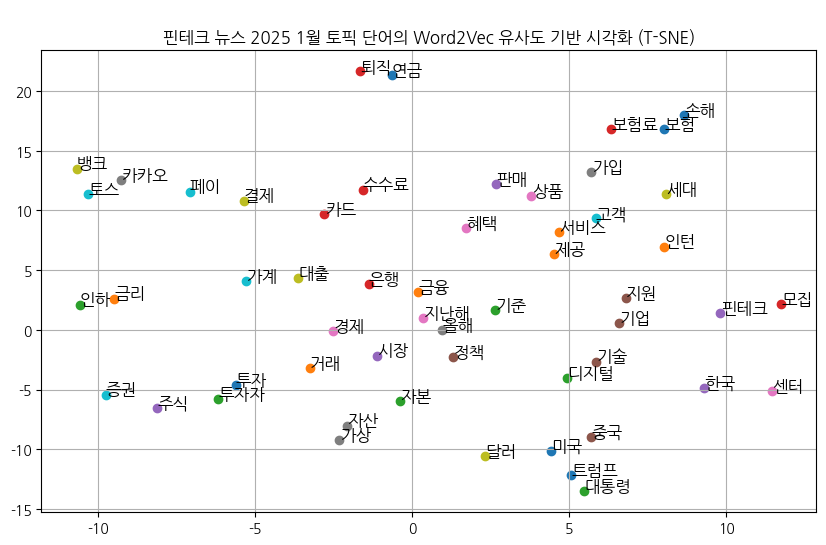

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 2월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.3947
토픽수: 3, Coherence Score: 0.4800
토픽수: 4, Coherence Score: 0.5018
토픽수: 5, Coherence Score: 0.5588
토픽수: 6, Coherence Score: 0.5779
토픽수: 7, Coherence Score: 0.6027
토픽수: 8, Coherence Score: 0.6164
최적 토픽수: 8 (Score: 0.6164)

핀테크 뉴스 2025 2월 토픽별 상위 단어 (k=8)
Topic #0: ['거래', '거래소', '대출', '금융', '시장', '예금', '기준', '인하', '은행', '금리']
Topic #1: ['자본', '강화', '시장', '계획', '당국', '회사', '관련', '검사', '금감원', '금융']
Topic #2: ['시장', '투자', '경제', '대통령', '정책', '관세', '달러', '트럼프', '중국', '미국']
Topic #3: ['저축', '신용', '카드', '가계', '증가', '뱅크', '지난해', '금융', '대출', '은행']
Topic #4: ['가입', '판매', '수익', '지난해', '금융', '증권', '연금', '투자', '상품', '보험']
Topic #5: ['서비스', '데이터', '투자', '금융', '지원', '사업', '가상', '핀테크', '자산', '기업']
Topic #6: ['서비스', '비용', '기업', '핀테크', '지원', '수수료', '금융', '결제', '페이', '카드']
Topic #7: ['업계', '유통', '손해', '자동차', '기업', '조각', '증권', '보험', '발행', '투자']

핀테크 뉴스 2025 2월 토픽 단어 총 59개
word2vec에 포함된 토픽 단어 수: 59개


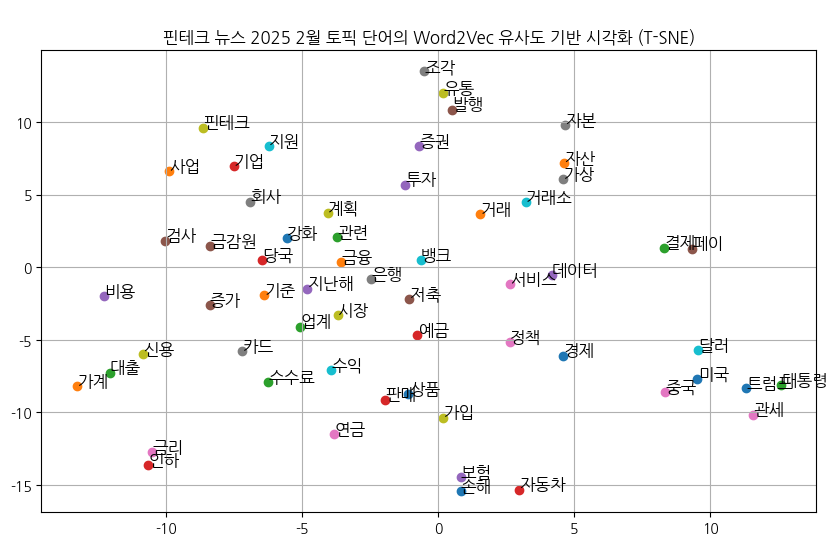

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 3월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4130
토픽수: 3, Coherence Score: 0.4105
토픽수: 4, Coherence Score: 0.4142
토픽수: 5, Coherence Score: 0.4594
토픽수: 6, Coherence Score: 0.4972
토픽수: 7, Coherence Score: 0.5865
토픽수: 8, Coherence Score: 0.5768
최적 토픽수: 7 (Score: 0.5865)

핀테크 뉴스 2025 3월 토픽별 상위 단어 (k=7)
Topic #0: ['은행', '결제', '점포', '가입', '계좌', '화폐', '발행', '디지털', '금융', '연금']
Topic #1: ['접수', '비용', '테스트', '심사', '모집', '사업', '핀테크', '금융', '기업', '지원']
Topic #2: ['대통령', '투자', '경제', '시장', '기업', '관세', '트럼프', '달러', '중국', '미국']
Topic #3: ['기관', '관련', '금감원', '시스템', '강화', '규제', '기업', '시장', '투자', '금융']
Topic #4: ['보험료', '거래', '금융', '상품', '결제', '수수료', '서비스', '페이', '카드', '보험']
Topic #5: ['상품', '가계', '기준', '지난해', '공매도', '저축', '금융', '금리', '대출', '은행']
Topic #6: ['투자', '서비스', '증권', '대출', '가상', '신용', '자산', '뱅크', '금융', '은행']

핀테크 뉴스 2025 3월 토픽 단어 총 54개
word2vec에 포함된 토픽 단어 수: 54개


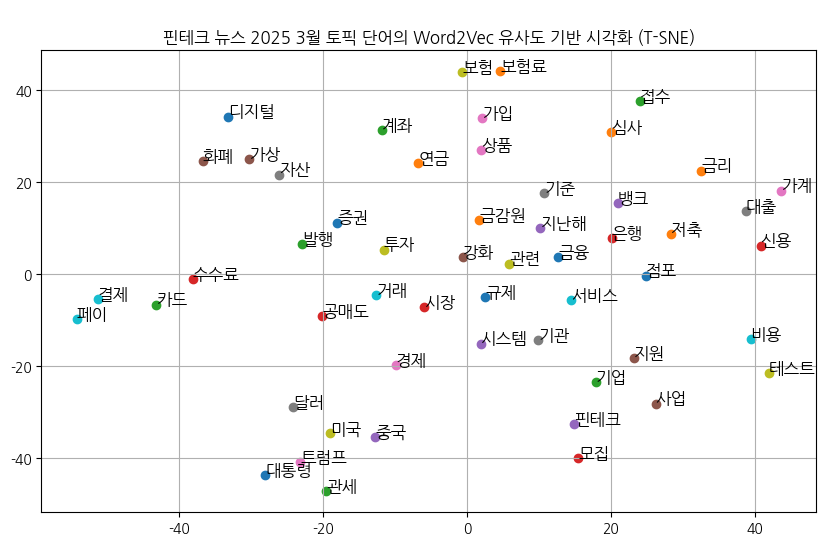

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 4월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4288
토픽수: 3, Coherence Score: 0.5058
토픽수: 4, Coherence Score: 0.5420
토픽수: 5, Coherence Score: 0.5663
토픽수: 6, Coherence Score: 0.5782
토픽수: 7, Coherence Score: 0.5712
토픽수: 8, Coherence Score: 0.5495
최적 토픽수: 6 (Score: 0.5782)

핀테크 뉴스 2025 4월 토픽별 상위 단어 (k=6)
Topic #0: ['평가', '기준', '테스트', '비용', '기업', '금융', '지원', '금리', '은행', '대출']
Topic #1: ['무역', '경제', '시장', '기업', '대통령', '달러', '트럼프', '중국', '관세', '미국']
Topic #2: ['참여', '스타트업', '모집', '한국', '센터', '핀테크', '기술', '기업', '지원', '금융']
Topic #3: ['달러', '금융', '시장', '은행', '가상', '디지털', '스테이', '결제', '자산', '코인']
Topic #4: ['제공', '토스', '뱅크', '은행', '상품', '고객', '카드', '보험', '금융', '서비스']
Topic #5: ['연금', '자본', '보험', '수익', '자산', '증권', '시장', '은행', '투자', '금융']

핀테크 뉴스 2025 4월 토픽 단어 총 45개
word2vec에 포함된 토픽 단어 수: 45개


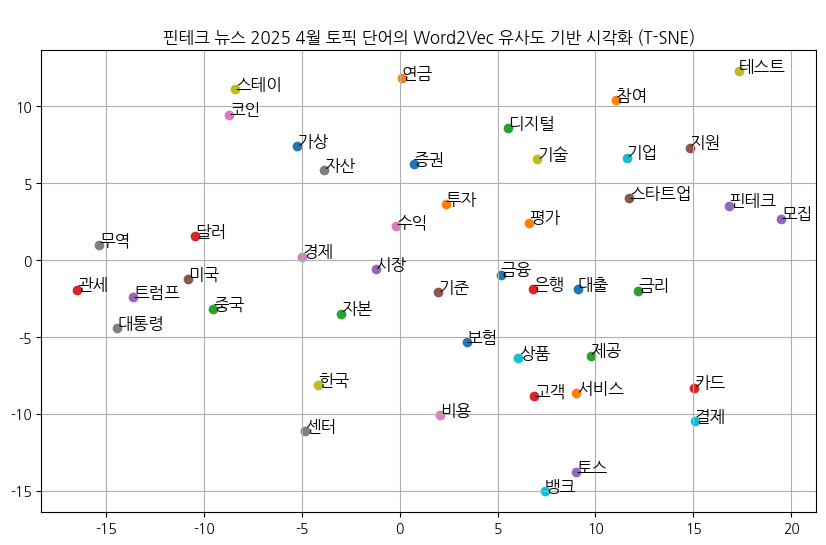

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 5월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4339
토픽수: 3, Coherence Score: 0.4105
토픽수: 4, Coherence Score: 0.4638
토픽수: 5, Coherence Score: 0.5304
토픽수: 6, Coherence Score: 0.5341
토픽수: 7, Coherence Score: 0.5481
토픽수: 8, Coherence Score: 0.5476
최적 토픽수: 7 (Score: 0.5481)

핀테크 뉴스 2025 5월 토픽별 상위 단어 (k=7)
Topic #0: ['혜택', '심사', '핀테크', '접수', '지원', '지역', '모집', '금융', '외국인', '카드']
Topic #1: ['금융', '거래', '시장', '디지털', '가상', '달러', '결제', '자산', '스테이', '코인']
Topic #2: ['정보', '제공', '토스', '상품', '연금', '은행', '뱅크', '고객', '서비스', '금융']
Topic #3: ['센터', '평가', '비용', '금융', '접수', '신청', '테스트', '핀테크', '기업', '지원']
Topic #4: ['달러', '대통령', '무역', '경제', '시장', '트럼프', '관세', '중국', '미국', '보험']
Topic #5: ['증가', '예금', '신용', '기준', '저축', '분기', '금융', '금리', '대출', '은행']
Topic #6: ['투자자', '규제', '상장', '펀드', '증권', '기업', '자본', '시장', '투자', '금융']

핀테크 뉴스 2025 5월 토픽 단어 총 57개
word2vec에 포함된 토픽 단어 수: 57개


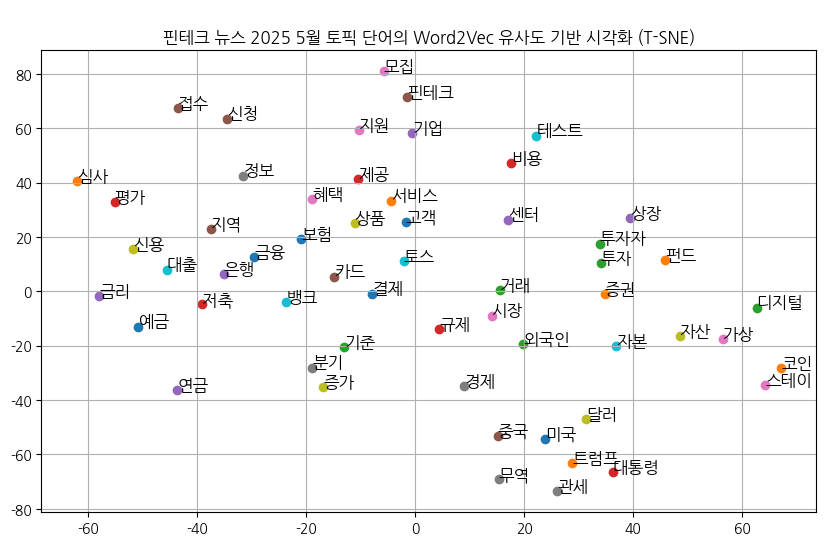

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 6월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4731
토픽수: 3, Coherence Score: 0.4533
토픽수: 4, Coherence Score: 0.5525
토픽수: 5, Coherence Score: 0.5471
토픽수: 6, Coherence Score: 0.5863
토픽수: 7, Coherence Score: 0.6085
토픽수: 8, Coherence Score: 0.5817
최적 토픽수: 7 (Score: 0.6085)

핀테크 뉴스 2025 6월 토픽별 상위 단어 (k=7)
Topic #0: ['기업', '증권', '상품', '자산', '연금', '서비스', '금융', '시장', '데이터', '투자']
Topic #1: ['제출', '평가', '테스트', '접수', '신청', '투자', '금융', '핀테크', '기업', '지원']
Topic #2: ['인하', '예금', '주택', '증가', '기준', '가계', '금융', '은행', '금리', '대출']
Topic #3: ['트럼프', '경제', '일본', '자본', '투자', '정책', '기업', '달러', '시장', '미국']
Topic #4: ['통제', '보험료', '상품', '판매', '계약', '보장', '손해', '미국', '중국', '보험']
Topic #5: ['확대', '제공', '신용', '대출', '토스', '고객', '서비스', '뱅크', '은행', '금융']
Topic #6: ['시장', '발행', '디지털', '금융', '페이', '자산', '카드', '결제', '스테이', '코인']

핀테크 뉴스 2025 6월 토픽 단어 총 54개
word2vec에 포함된 토픽 단어 수: 54개


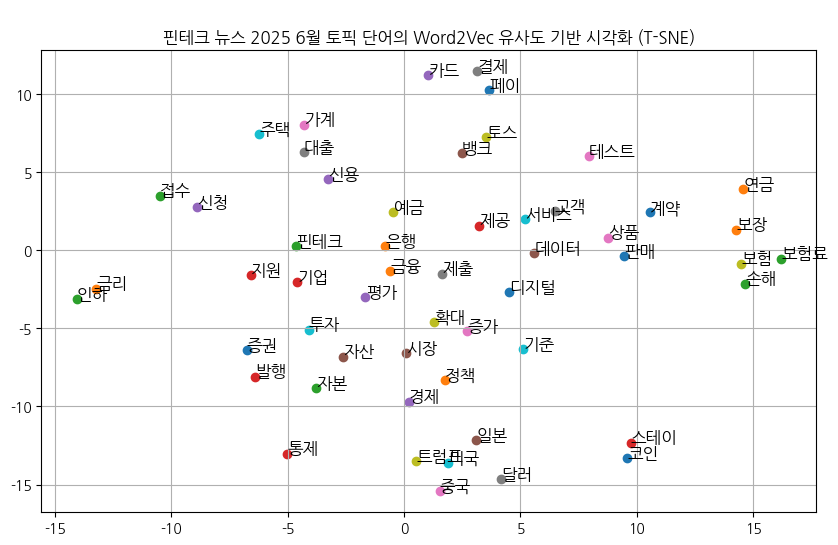

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 7월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.5187
토픽수: 3, Coherence Score: 0.4681
토픽수: 4, Coherence Score: 0.5680
토픽수: 5, Coherence Score: 0.5683
토픽수: 6, Coherence Score: 0.5363
토픽수: 7, Coherence Score: 0.5085
토픽수: 8, Coherence Score: 0.5748
최적 토픽수: 8 (Score: 0.5748)

핀테크 뉴스 2025 7월 토픽별 상위 단어 (k=8)
Topic #0: ['대출', '수수료', '토스', '금융', '고객', '카드', '서비스', '카카오', '은행', '뱅크']
Topic #1: ['국가', '합의', '무역', '협상', '달러', '대통령', '트럼프', '관세', '중국', '미국']
Topic #2: ['거래소', '자산', '거래', '페이', '서비스', '금융', '결제', '시장', '투자', '보험']
Topic #3: ['자산', '투자', '기준', '수익', '예금', '상품', '저축', '금리', '은행', '금융']
Topic #4: ['담보', '카드', '주택', '규제', '보험', '금리', '가계', '금융', '은행', '대출']
Topic #5: ['은행', '결제', '발행', '달러', '디지털', '시장', '금융', '자산', '스테이', '코인']
Topic #6: ['교육', '기술', '보이스', '피싱', '활용', '과정', '평가', '정보', '데이터', '금융']
Topic #7: ['제공', '한국', '서류', '센터', '교육', '신청', '참여', '지원', '핀테크', '기업']

핀테크 뉴스 2025 7월 토픽 단어 총 60개
word2vec에 포함된 토픽 단어 수: 60개


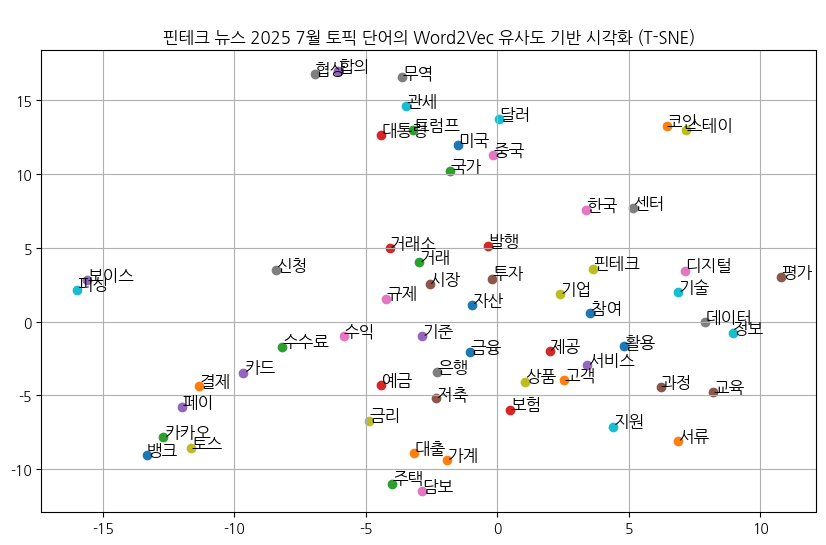

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 8월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4821
토픽수: 3, Coherence Score: 0.4789
토픽수: 4, Coherence Score: 0.5652
토픽수: 5, Coherence Score: 0.5788
토픽수: 6, Coherence Score: 0.5801
토픽수: 7, Coherence Score: 0.5875
토픽수: 8, Coherence Score: 0.5939
최적 토픽수: 8 (Score: 0.5939)

핀테크 뉴스 2025 8월 토픽별 상위 단어 (k=8)
Topic #0: ['인하', '규제', '시장', '가계', '기준', '신용', '금리', '은행', '금융', '대출']
Topic #1: ['금융', '참여', '진출', '발표', '서류', '신청', '해외', '지원', '기업', '핀테크']
Topic #2: ['고객', '분석', '기반', '참여', '활용', '정보', '서비스', '지원', '데이터', '금융']
Topic #3: ['사례', '경제', '정부', '기업', '대통령', '트럼프', '관세', '금융', '중국', '미국']
Topic #4: ['토스', '고객', '금융', '카카오', '페이', '은행', '뱅크', '서비스', '결제', '카드']
Topic #5: ['참여', '대상', '기업', '센터', '한국', '지원', '금융', '과정', '핀테크', '교육']
Topic #6: ['예금', '보험료', '손해', '가입', '상품', '금융', '연금', '저축', '은행', '보험']
Topic #7: ['디지털', '달러', '가상', '기업', '금융', '투자', '시장', '자산', '스테이', '코인']

핀테크 뉴스 2025 8월 토픽 단어 총 60개
word2vec에 포함된 토픽 단어 수: 60개


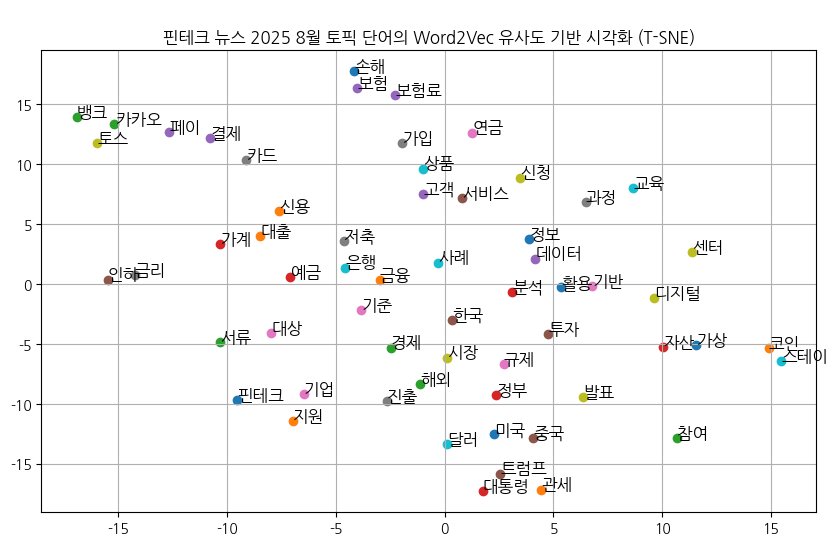

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 9월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.3573
토픽수: 3, Coherence Score: 0.4175
토픽수: 4, Coherence Score: 0.4604
토픽수: 5, Coherence Score: 0.4740
토픽수: 6, Coherence Score: 0.4688
토픽수: 7, Coherence Score: 0.5252
토픽수: 8, Coherence Score: 0.5209
최적 토픽수: 7 (Score: 0.5252)

핀테크 뉴스 2025 9월 토픽별 상위 단어 (k=7)
Topic #0: ['주식', '투자자', '중국', '성장', '거래', '글로벌', '기업', '미국', '투자', '시장']
Topic #1: ['신용', '정부', '뱅크', '소비자', '기업', '금리', '규제', '대출', '은행', '금융']
Topic #2: ['자산', '고객', '투자', '서비스', '연금', '은행', '상품', '금융', '카드', '금리']
Topic #3: ['개발', '고객', '보안', '활용', '중국', '금융', '기술', '기업', '데이터', '서비스']
Topic #4: ['미국', '가상', '결제', '디지털', '달러', '발행', '금융', '자산', '스테이', '코인']
Topic #5: ['증가', '생명', '상품', '보험금', '손해', '참여', '지원', '핀테크', '기업', '보험']
Topic #6: ['심사', '대상', '한국', '아이디어', '신청', '센터', '교육', '금융', '지원', '핀테크']

핀테크 뉴스 2025 9월 토픽 단어 총 52개
word2vec에 포함된 토픽 단어 수: 52개


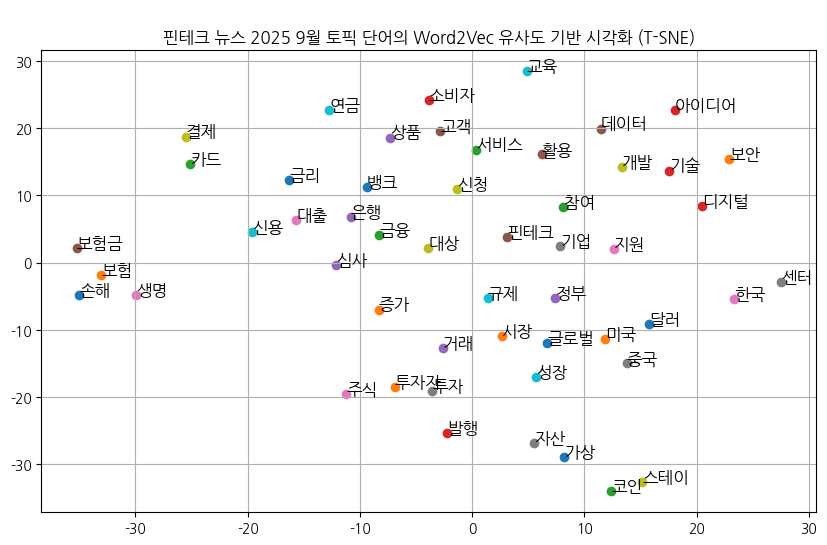

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 10월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4133
토픽수: 3, Coherence Score: 0.4245
토픽수: 4, Coherence Score: 0.4338
토픽수: 5, Coherence Score: 0.4325
토픽수: 6, Coherence Score: 0.4681
토픽수: 7, Coherence Score: 0.4749
토픽수: 8, Coherence Score: 0.5270
최적 토픽수: 8 (Score: 0.5270)

핀테크 뉴스 2025 10월 토픽별 상위 단어 (k=8)
Topic #0: ['가계', '규제', '저축', '데이터', '신용', '뱅크', '금리', '금융', '은행', '대출']
Topic #1: ['전망', '은행', '인하', '기준', '투자', '시장', '분기', '금융', '수익', '금리']
Topic #2: ['투자', '소비자', '위원회', '거래', '보호', '보안', '서비스', '은행', '정보', '금융']
Topic #3: ['미국', '시장', '중국', '기술', '자산', '산업', '기업', '스테이', '코인', '금융']
Topic #4: ['생명', '손해', '제도', '보험금', '보험료', '금융', '연금', '상품', '카드', '보험']
Topic #5: ['과정', '한국', '참여', '금융', '신청', '센터', '교육', '기업', '지원', '핀테크']
Topic #6: ['주식', '투자자', '가상', '거래소', '거래', '투자', '시장', '미국', '자산', '달러']
Topic #7: ['협력', '제공', '기술', '투자', '네이버', '스타트업', '페이', '서비스', '기업', '결제']

핀테크 뉴스 2025 10월 토픽 단어 총 60개
word2vec에 포함된 토픽 단어 수: 60개


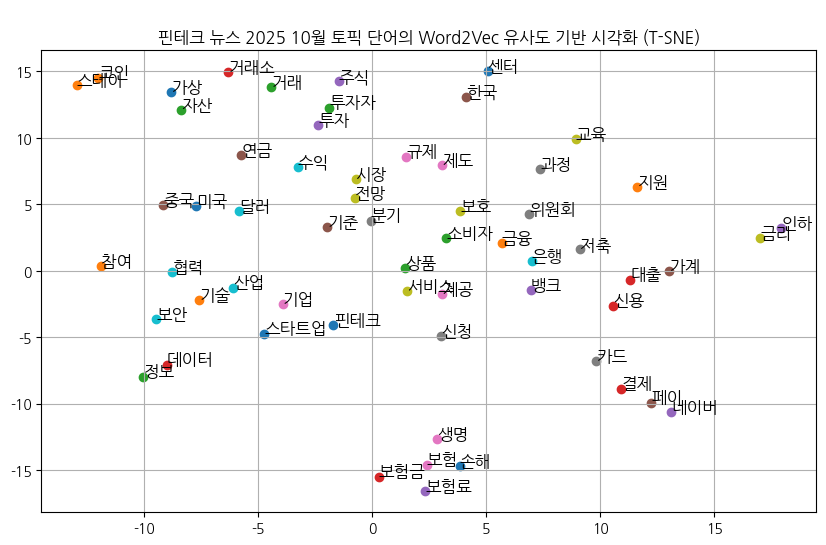

--- 토픽 모델링 시작 ---

핀테크 뉴스 2025 11월 최적 토픽 수 계산 중...


/home/user/miniforge3/envs/fintech2/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


토픽수: 2, Coherence Score: 0.4255
토픽수: 3, Coherence Score: 0.4205
토픽수: 4, Coherence Score: 0.4578
토픽수: 5, Coherence Score: 0.4864
토픽수: 6, Coherence Score: 0.5245
토픽수: 7, Coherence Score: 0.4845
토픽수: 8, Coherence Score: 0.4682
최적 토픽수: 6 (Score: 0.5245)

핀테크 뉴스 2025 11월 토픽별 상위 단어 (k=6)
Topic #0: ['주식', '자본', '투자자', '발행', '거래', '증권', '자산', '시장', '금융', '투자']
Topic #1: ['금융', '산업', '투자', '경제', '정부', '기업', '달러', '중국', '데이터', '미국']
Topic #2: ['카카오', '증가', '신용', '뱅크', '분기', '금융', '카드', '금리', '대출', '은행']
Topic #3: ['데이터', '활용', '시장', '기반', '기술', '디지털', '기업', '서비스', '결제', '금융']
Topic #4: ['보험료', '지주', '대출', '개선', '소비자', '관리', '당국', '자본', '보험', '금융']
Topic #5: ['한국', '센터', '참여', '교육', '신청', '스테이', '코인', '기업', '지원', '핀테크']

핀테크 뉴스 2025 11월 토픽 단어 총 49개
word2vec에 포함된 토픽 단어 수: 49개


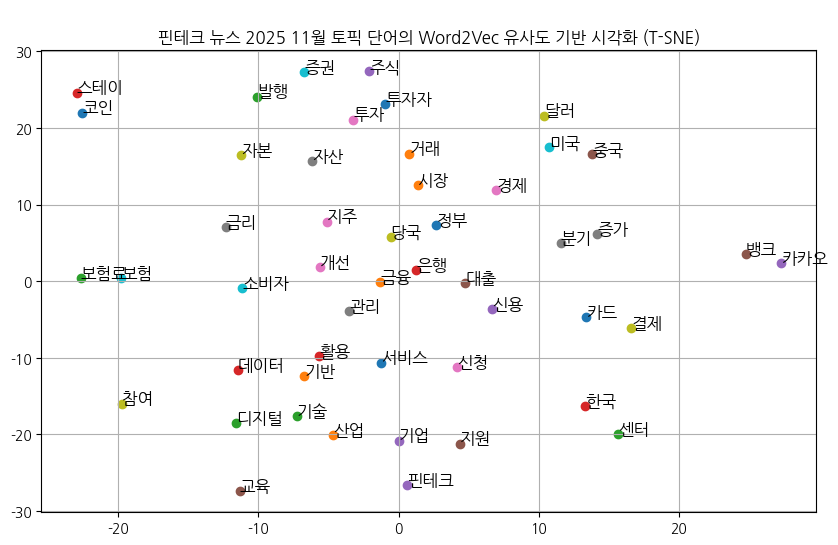

In [27]:
for month in range(1,12):
    topic_modeling(df.loc[df['날짜'].dt.month == month, 'tokens'], w2v_model, month)

In [29]:
# !pip install python-dotenv
# !pip install google-genai

In [41]:
import os
from dotenv import load_dotenv
load_dotenv("./.env_gemini")
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')

In [42]:
from google import genai

In [ ]:
# The client gets the API key from the environment variable `GEMINI_API_KEY`.
client = genai.Client(api_key=GEMINI_API_KEY)

response = client.models.generate_content(
    model="gemini-2.5-flash", contents="핀테크에 대해서 알려줘"
)
print(response.text)

# 핀테크 뉴스 제목을 분기별로 gemini에게 요약시키고 아이디어 물어보기

In [45]:
titles = " ".join(df.loc[(df['날짜'].dt.month >= 1) & (df['날짜'].dt.month <= 3), '제목'].tolist())

In [46]:
len(titles)

94523

In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash", contents=f"""{titles}\n위의 글은 핀테크 관련 뉴스 제목들이야
    이 제목을 분석해서 어떤 이슈들이 중요한 사건이었는지 분석하고, 그 내용을 토대로
    새로운 핀테스 서비스를 기획할 때 사용할 수 있을 만한 아이디어 5개 제시해줘"""
)
print(response.text)

# 분기별로 분석

In [ ]:
results = ""
for mon in range(1, 13, 3):
    titles = " ".join(df.loc[(df['날짜'].dt.month >= mon) & (df['날짜'].dt.month <= mon+2), '제목'].tolist())
    response = client.models.generate_content(
    model="gemini-2.5-flash", contents=f"""{titles}\n위의 글은 핀테크 관련 뉴스 제목들이야
    이 제목을 분석해서 어떤 이슈들이 중요한 사건이었는지 분석하고, 그 내용을 토대로
    새로운 핀테스 서비스를 기획할 때 사용할 수 있을 만한 아이디어 5개 제시해줘"""
)
    results += "\n" + response.text
print(results)

In [ ]:
print(response.text)